In [2]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt 

Load Image


In [3]:
def read_file(filename):
    img=cv2.imread(filename)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.show()
    return img

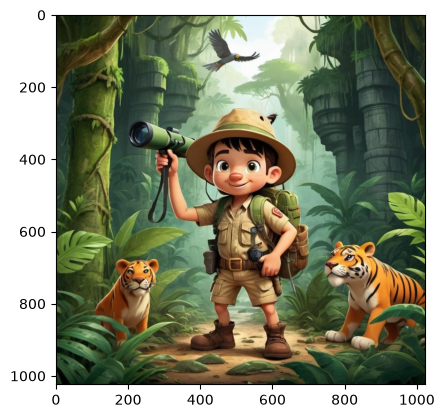

In [4]:
filename="images.png"
img=read_file(filename)

#CREATE EDGE MASK

In [5]:
def edge_mask(img,line_size,blur_value):
    #takes input img and gives output of image
    gray=cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
    gray_blur=cv2.medianBlur(gray,blur_value)
    edges=cv2.adaptiveThreshold(gray_blur,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,
    line_size,blur_value)

    return edges

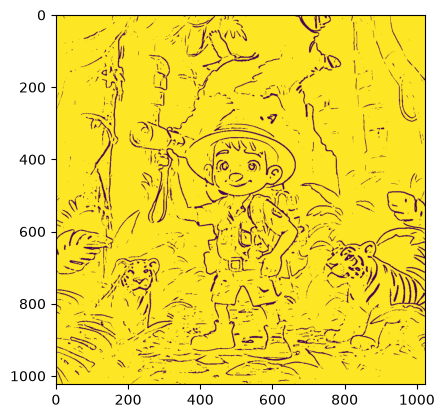

In [6]:
line_size,blur_value=7,7

edges=edge_mask(img,line_size,blur_value)
plt.imshow(edges)
plt.show()

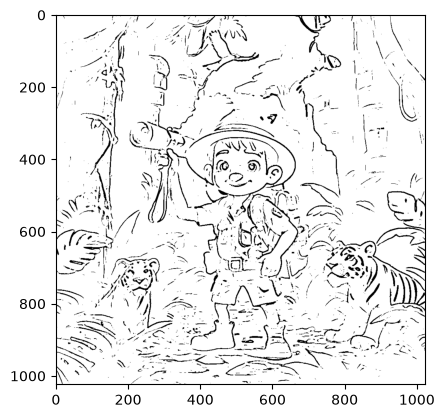

In [7]:
line_size,blur_value=7,7

edges=edge_mask(img,line_size,blur_value)
plt.imshow(edges,cmap="grey")
plt.show()

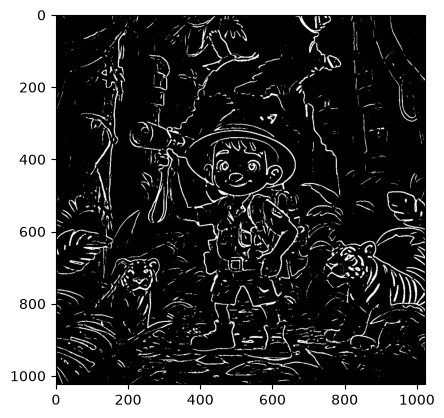

In [8]:
line_size,blur_value=7,7

edges=edge_mask(img,line_size,blur_value)
plt.imshow(edges,cmap="binary")
plt.show()

REDUCE THE COLOR PALETTE 

In [9]:
def color_quantization(img, k):
    #transform image
    data=np.float32(img).reshape((-1,3))

    #determine criteria
    criteria=(cv2.TERM_CRITERIA_EPS+ cv2.TERM_CRITERIA_MAX_ITER,20,0.001)

    #Implement Kmean
    ret,label,center =cv2.kmeans(data,k,None,criteria,10,cv2.KMEANS_RANDOM_CENTERS)
    center=np.uint8(center)

    result=center[label.flatten()]
    result=result.reshape(img.shape)
    
    return result


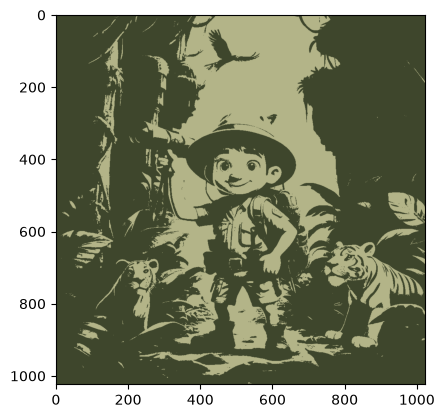

In [10]:
img= color_quantization(img, k=2)
plt.imshow(img)
plt.show()

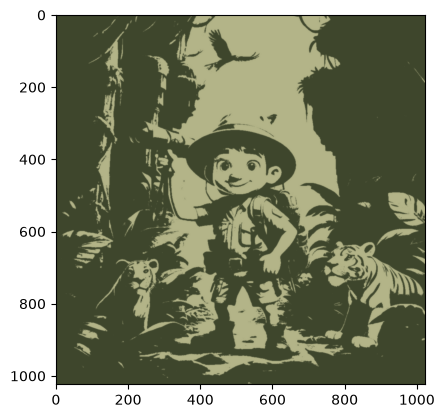

In [11]:
#Reduce noise
blurred=cv2.bilateralFilter(img,d=7,sigmaColor=200,sigmaSpace=200)

plt.imshow(blurred)
plt.show()

Combine Edge Mask with quantiz img

In [ ]:
# Combine the blurred image and the edge mask to create the cartoon drawing
cartoon = cv2.bitwise_and(blurred, blurred, mask=edges)

plt.imshow(cartoon)
plt.show()